In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [5]:
df = pd.read_csv('./src/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,3.25,41.97,0
1,2.93,27.00,1
2,3.32,23.88,1
3,3.76,24.25,0
4,2.88,8.91,0


C:\Users\MuhammadAbdullah\AppData\Local\Temp\ipykernel_24348\3582099395.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\MuhammadAbdullah\AppData\Local\Temp\ipykernel_24348\3582099395.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


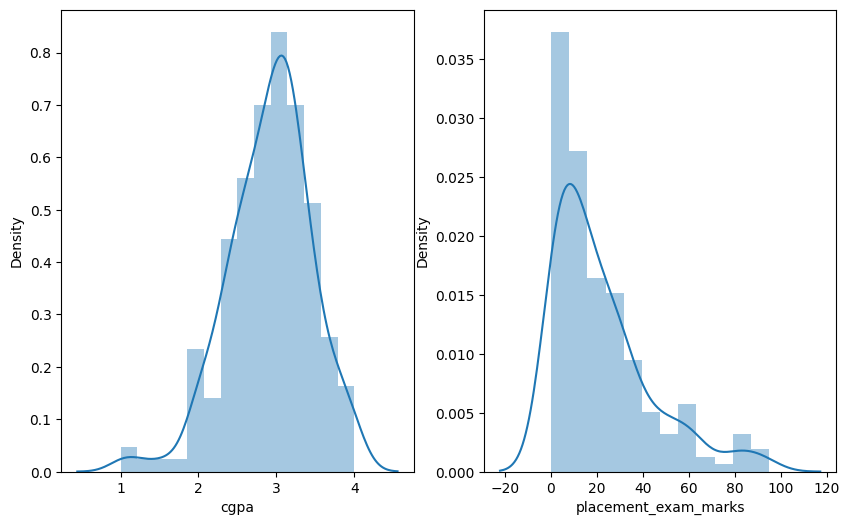

In [6]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])
plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])
plt.show()

In [7]:
df['placement_exam_marks'].skew()

np.float64(1.3965250639557438)

In [8]:
df.describe()

,cgpa,placement_exam_marks,placed
count,200.000000,200.000000,200.000000
mean,2.914650,22.180250,0.515000
std,0.534712,21.369446,0.501029
min,1.000000,0.220000,0.000000
25%,2.587500,6.607500,0.000000
50%,2.970000,15.860000,1.000000
75%,3.240000,31.447500,1.000000
max,4.000000,95.000000,1.000000


<Axes: ylabel='placement_exam_marks'>

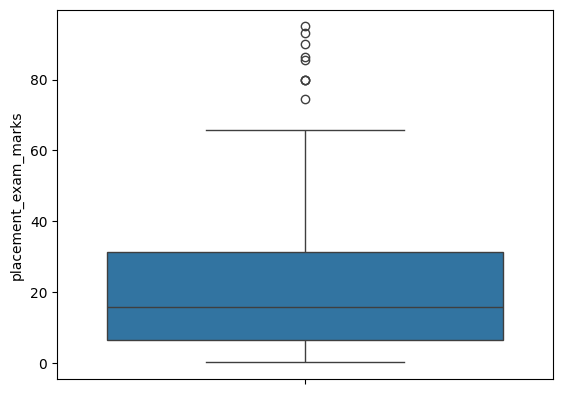

In [9]:
sns.boxplot(df['placement_exam_marks'])

In [11]:
# Find the IQR
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(24.839999999999996)

In [12]:
Upper_limit = Q3 + 1.5*IQR
Lower_limit = Q1 - 1.5*IQR
Upper_limit, Lower_limit

(np.float64(68.70749999999998), np.float64(-30.65249999999999))

In [13]:
df[df['placement_exam_marks'] > Upper_limit]

,cgpa,placement_exam_marks,placed
8,1.09,80.00,1
13,2.00,80.00,0
14,2.00,80.00,1
16,2.00,90.00,0
19,2.29,95.00,0
41,3.09,74.47,1
126,2.50,93.14,1
177,3.73,86.31,1
182,2.46,85.38,1


In [14]:
df[df['placement_exam_marks']<Lower_limit]

,cgpa,placement_exam_marks,placed


### Trimming

In [15]:
new_df = df[df['placement_exam_marks'] < Upper_limit]
new_df

,cgpa,placement_exam_marks,placed
0,3.25,41.97,0
1,2.93,27.00,1
2,3.32,23.88,1
3,3.76,24.25,0
4,2.88,8.91,0
...,...,...,...
195,3.19,2.53,1
196,2.56,2.50,0
197,3.08,20.95,0
198,3.03,27.41,0


In [16]:
new_df.describe()

,cgpa,placement_exam_marks,placed
count,191.000000,191.000000,191.000000
mean,2.941204,19.223822,0.507853
std,0.510208,16.764094,0.501252
min,1.000000,0.220000,0.000000
25%,2.615000,6.040000,0.000000
50%,2.990000,14.530000,1.000000
75%,3.240000,28.225000,1.000000
max,4.000000,65.750000,1.000000


C:\Users\MuhammadAbdullah\AppData\Local\Temp\ipykernel_24348\952244779.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\MuhammadAbdullah\AppData\Local\Temp\ipykernel_24348\952244779.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam

<Axes: ylabel='placement_exam_marks'>

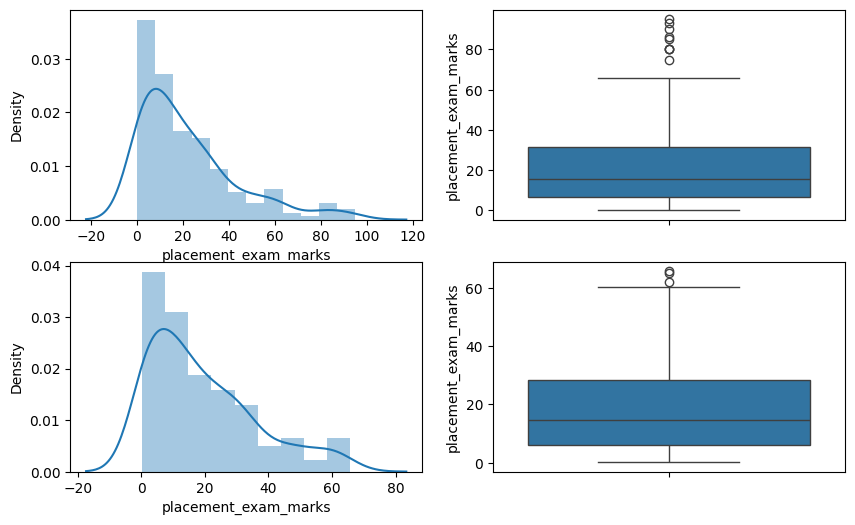

In [17]:
# comparing

plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])
plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

### Capping

In [21]:
new_df_cap = df.copy()
new_df_cap['placement_exam_marks'] = np.where(new_df_cap['placement_exam_marks']>Upper_limit, Upper_limit, new_df_cap['placement_exam_marks'])
new_df_cap

,cgpa,placement_exam_marks,placed
0,3.25,41.97,0
1,2.93,27.00,1
2,3.32,23.88,1
3,3.76,24.25,0
4,2.88,8.91,0
...,...,...,...
195,3.19,2.53,1
196,2.56,2.50,0
197,3.08,20.95,0
198,3.03,27.41,0


In [22]:
new_df_cap.describe()

,cgpa,placement_exam_marks,placed
count,200.000000,200.000000,200.000000
mean,2.914650,21.450588,0.515000
std,0.534712,19.341241,0.501029
min,1.000000,0.220000,0.000000
25%,2.587500,6.607500,0.000000
50%,2.970000,15.860000,1.000000
75%,3.240000,31.447500,1.000000
max,4.000000,68.707500,1.000000


C:\Users\MuhammadAbdullah\AppData\Local\Temp\ipykernel_24348\1516777499.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\MuhammadAbdullah\AppData\Local\Temp\ipykernel_24348\1516777499.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placemen

<Axes: ylabel='placement_exam_marks'>

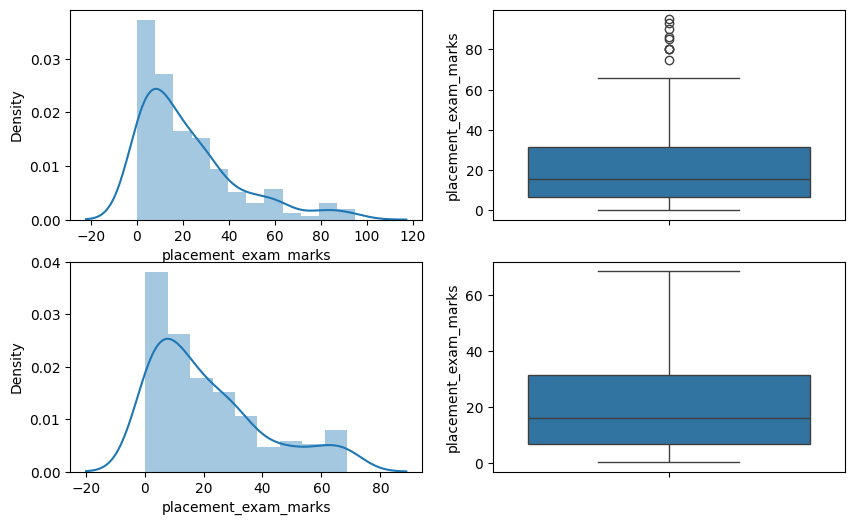

In [23]:
# comparing

plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])
plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])